# Import

In [78]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

# Load preprocessed dataset

In [85]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"

train_df = pd.read_csv(DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
# train_df.head(20)
positive = train_df[train_df["label"] == 1].head(2)
negative = train_df[train_df["label"] == 0].head(2)

display(pd.concat([positive, negative]))

Training shape: (24904, 2)
Testing shape: (24801, 2)


,processed_text,label
0,bromwell high cartoon comedy ran time program ...,1
1,homelessness houselessness george carlin state...,1
12472,story man unnatural feeling pig start opening ...,0
12473,airport 77 start brand new luxury 747 plane lo...,0


# Configure device

In [29]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Using device: cuda
GPU: NVIDIA GeForce MX570 A


# Train validation test split

In [30]:
from sklearn.model_selection import train_test_split
train_data, val_data=train_test_split(train_df,test_size=0.2,random_state=SEED,stratify=train_df["label"])  
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_df))

print("\nTraining labels:")
print(train_data["label"].value_counts())

print("\nValidation labels:")
print(val_data["label"].value_counts())

Training samples: 19923
Validation samples: 4981
Testing samples: 24801

Training labels:
label
1    9977
0    9946
Name: count, dtype: int64

Validation labels:
label
1    2495
0    2486
Name: count, dtype: int64


# Vocabulary construction

In [31]:
from collections import Counter

In [32]:
# build the vocabulary using only the training set
train_tokens=train_data["processed_text"].str.split()
word_counts=Counter()
for tokens in train_tokens:
    word_counts.update(tokens)
word_counts

Counter({'not': 47596,
         'movie': 41504,
         'film': 37415,
         'one': 22135,
         'like': 16561,
         'time': 12688,
         'would': 12366,
         'good': 12291,
         'character': 11309,
         'story': 10435,
         'no': 10051,
         'even': 10044,
         'get': 10033,
         'make': 9712,
         'see': 9514,
         'really': 9400,
         'well': 8592,
         'scene': 8434,
         'much': 7863,
         'people': 7547,
         'could': 7522,
         'bad': 7443,
         'also': 7373,
         'great': 7292,
         'first': 7216,
         'way': 7051,
         'show': 6903,
         'made': 6666,
         'thing': 6558,
         'life': 6537,
         'think': 6208,
         'go': 6104,
         'know': 5711,
         'watch': 5702,
         'plot': 5513,
         'year': 5499,
         'love': 5492,
         'actor': 5476,
         'two': 5465,
         'seen': 5391,
         'many': 5309,
         'end': 5301,
         'loo

In [33]:
# create the vocabulary
word_to_idx={
    "<PAD>":0,
    "<UNK>":1
}
for word, _ in word_counts.items():
    word_to_idx[word]=len(word_to_idx)
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

In [34]:
# check
print(f"Vocabulary size: {len(word_to_idx):,}")

print("\nFirst 10 words:")
for word, idx in list(word_to_idx.items())[:10]:
    print(f"{word}: {idx}")

Vocabulary size: 60,725

First 10 words:
<PAD>: 0
<UNK>: 1
saddens: 2
rate: 3
movie: 4
lot: 5
favorite: 6
actor: 7
location: 8
genre: 9


# Integer Encoding

## encoding function

In [35]:
def encode_review(tokens, vocabulary):
    encoded_review = []

    for word in tokens:
        if word in vocabulary:
            encoded_review.append(vocabulary[word])
        else:
            encoded_review.append(vocabulary["<UNK>"])

    return encoded_review

In [36]:
print(word_to_idx["<UNK>"])

1


## convert string into list of tokens

In [37]:
train_tokens = train_data["processed_text"].str.split()
val_tokens = val_data["processed_text"].str.split()
test_tokens = test_df["processed_text"].str.split()

## encode

In [38]:
train_sequences = train_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

val_sequences = val_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

test_sequences = test_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

In [39]:
print("Original review:")
print(train_tokens.iloc[0])

print("\nEncoded review:")
print(train_sequences.iloc[0])

Original review:
['saddens', 'rate', 'movie', 'lot', 'favorite', 'actor', 'location', 'genre', 'e', 'douglas', 'sutherland', 'washington', 'c', 'political', 'thriller', 'sentinel', 'really', 'hit', 'low', 'like', 'great', 'idea', 'front', 'signed', 'right', 'cast', 'great', 'city', 'shot', 'took', 'holiday', 'letting', 'remaining', 'crew', 'improvise', 'rest', 'wish', 'could', 'blame', 'yet', 'another', 'bland', 'performance', 'basinger', 'not', 'feel', 'one', 'worst', 'actor', 'hollywood', 'still', 'steaming', 'decade', 'later', 'one', 'definitely', 'bad', 'actor', 'film', 'win', 'acting', 'oscar', 'l', 'confidential', 'not', 'problem', 'sutherland', 'love', 'jack', 'bauer', '24', 'play', 'jack', 'miss', 'old', 'time', 'kill', 'good', 'men', 'day', 'douglas', 'certainly', 'took', 'hiatus', 'acting', 'phoned', 'one', 'plot', 'someone', 'secret', 'service', 'traitor', 'want', 'president', 'dead', 'douglas', 'haphazardly', 'framed', 'someone', 'believe', 'actually', 'no', 'spoiler', 'qui

# Sequence padding

## sequence length analysis

In [40]:
sequence_lengths = train_sequences.apply(len)
print(sequence_lengths.describe())

count    19923.000000
mean       124.483913
std         93.641799
min          6.000000
25%         66.000000
50%         93.000000
75%        151.000000
max       1449.000000
Name: processed_text, dtype: float64


In [41]:
print(f"90th percentile: {int(sequence_lengths.quantile(0.90))}")
print(f"95th percentile: {int(sequence_lengths.quantile(0.95))}")
print(f"99th percentile: {int(sequence_lengths.quantile(0.99))}")
print(f"Maximum length: {sequence_lengths.max()}")

90th percentile: 247
95th percentile: 321
99th percentile: 479
Maximum length: 1449


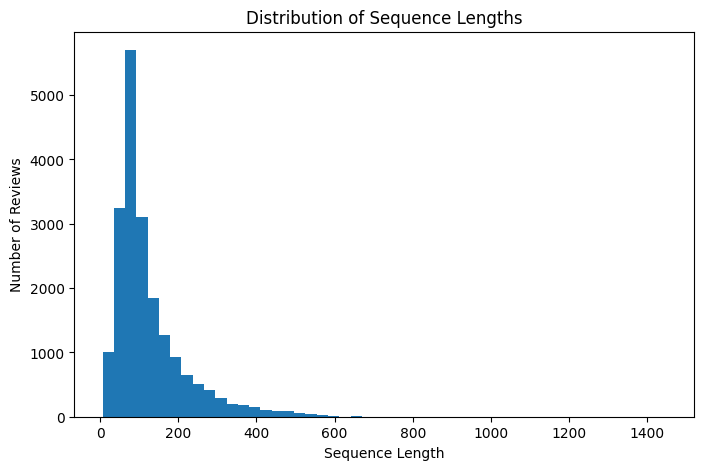

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sequence Lengths")
plt.show()

The maximum sequence length was set to 321 tokens, corresponding to the 95th percentile of the training review lengths. This preserves approximately 95% of the reviews without truncation while keeping the computational cost manageable

## padding

In [ ]:
MAX_LENGTH = 321
PAD_ID = word_to_idx["<PAD>"]

def pad_or_truncate(sequence, max_length, pad_id):
    if len(sequence) >= max_length:
        return sequence[:max_length]

    return sequence + [pad_id] * (max_length - len(sequence))

In [44]:
train_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in train_sequences
])

val_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in val_sequences
])

test_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in test_sequences
])

In [45]:
print("Training shape:", train_padded.shape)
print("Validation shape:", val_padded.shape)
print("Testing shape:", test_padded.shape)

print("First sequence length:", len(train_padded[0]))

Training shape: (19923, 321)
Validation shape: (4981, 321)
Testing shape: (24801, 321)
First sequence length: 321


# Prepare labels and seq lengths

In [90]:
train_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in train_sequences
])

val_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in val_sequences
])

test_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in test_sequences
])

y_train = train_data["label"].to_numpy(dtype=np.float32)
y_val = val_data["label"].to_numpy(dtype=np.float32)
y_test = test_df["label"].to_numpy(dtype=np.float32)

print("Training sequences:", train_padded.shape)
print("Training lengths:", train_lengths.shape)
print("Training labels:", y_train.shape)

Training sequences: (19923, 321)
Training lengths: (19923,)
Training labels: (19923,)


# Save Shared Data

In [86]:
SHARED_DIR = DATA_DIR / "shared"
SHARED_DIR.mkdir(parents=True, exist_ok=True)

In [88]:
import pickle

with open(SHARED_DIR / "vocabulary.pkl", "wb") as file:
    pickle.dump(
        {
            "word_to_idx": word_to_idx,
            "MAX_LENGTH": MAX_LENGTH
        },
        file
    )

print("Shared vocabulary saved successfully.")

Shared vocabulary saved successfully.


In [91]:
np.savez_compressed(
    SHARED_DIR / "sequence_data.npz",
    train_padded=train_padded,
    val_padded=val_padded,
    test_padded=test_padded,
    train_lengths=train_lengths,
    val_lengths=val_lengths,
    test_lengths=test_lengths,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

print("Shared sequence data saved successfully.")

Shared sequence data saved successfully.


# Word2Vec

In [46]:
# import time
# import gensim.downloader as api

# start_time = time.time()

# print("Loading pretrained Google News Word2Vec...")
# word2vec_model = api.load("word2vec-google-news-300")

# elapsed_time = time.time() - start_time

# print("Word2Vec loaded successfully.")
# print(f"Vector size: {word2vec_model.vector_size}")
# print(f"Loading time: {elapsed_time / 60:.2f} minutes")


## training on IMDB

In [47]:
from gensim.models import Word2Vec
import time

start_time = time.time()

word2vec_model = Word2Vec(
    sentences=train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=SEED
)

elapsed_time = time.time() - start_time

print("Word2Vec training completed.")
print("Vector size:", word2vec_model.vector_size)
print("Vocabulary size:", len(word2vec_model.wv))
print(f"Training time: {elapsed_time / 60:.2f} minutes")

Word2Vec training completed.
Vector size: 100
Vocabulary size: 37953
Training time: 1.68 minutes


In [48]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

## save the trained model


In [49]:
WORD2VEC_PATH = MODELS_DIR / "word2vec_imdb.model"
word2vec_model.save(str(WORD2VEC_PATH))
print("Word2Vec model saved to:", WORD2VEC_PATH)

Word2Vec model saved to: models\word2vec_imdb.model


## build word2Vec embedding matrix

In [50]:
word2vec_vectors = word2vec_model.wv
WORD2VEC_DIM = word2vec_vectors.vector_size

rng = np.random.default_rng(SEED)

word2vec_embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.05,
    size=(len(word_to_idx), WORD2VEC_DIM)
).astype(np.float32)

# Padding must stay zero
word2vec_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0

for word, idx in word_to_idx.items():
    if word in word2vec_vectors:
        word2vec_embedding_matrix[idx] = word2vec_vectors[word]
        matched_words += 1

word2vec_coverage = matched_words / len(word_to_idx) * 100

print("Word2Vec matrix shape:", word2vec_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {word2vec_coverage:.2f}%")

Word2Vec matrix shape: (60725, 100)
Matched words: 37953
Vocabulary coverage: 62.50%


## save the matrix

In [51]:
np.save(
    MODELS_DIR / "word2vec_embedding_matrix.npy",
    word2vec_embedding_matrix
)

print("Word2Vec embedding matrix saved.")

Word2Vec embedding matrix saved.


# GloVe

## load the pretrained glove model

In [52]:
import time
import gensim.downloader as api

start_time = time.time()

print("Loading pretrained GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

elapsed_time = time.time() - start_time

print("GloVe loaded successfully.")
print("Vector size:", glove_model.vector_size)
print(f"Loading time: {elapsed_time / 60:.2f} minutes")

Loading pretrained GloVe...
GloVe loaded successfully.
Vector size: 100
Loading time: 0.76 minutes


## create the glove embedded matrix

In [53]:
GLOVE_DIM = glove_model.vector_size

rng = np.random.default_rng(SEED)

glove_embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.05,
    size=(len(word_to_idx), GLOVE_DIM)
).astype(np.float32)

glove_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0

for word, idx in word_to_idx.items():
    if word in glove_model:
        glove_embedding_matrix[idx] = glove_model[word]
        matched_words += 1

glove_coverage = matched_words / len(word_to_idx) * 100

print("GloVe matrix shape:", glove_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {glove_coverage:.2f}%")

GloVe matrix shape: (60725, 100)
Matched words: 49464
Vocabulary coverage: 81.46%


## save the embedding matrix

In [54]:
np.save(
    MODELS_DIR / "glove_embedding_matrix.npy",
    glove_embedding_matrix
)

print("GloVe embedding matrix saved.")

GloVe embedding matrix saved.


In [55]:
# Save embedding matrix

np.save(
    MODELS_DIR / "word2vec_embedding_matrix.npy",
    word2vec_embedding_matrix
)

print("Word2Vec embedding matrix saved successfully.")

Word2Vec embedding matrix saved successfully.


# Pytorch dataset and data loaders

In [57]:
from torch.utils.data import Dataset, DataLoader
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )

        self.lengths = torch.tensor(
            lengths,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )

## create the datasets

In [58]:
train_dataset = ReviewDataset(
    train_padded,
    train_lengths,
    y_train
)

val_dataset = ReviewDataset(
    val_padded,
    val_lengths,
    y_val
)

test_dataset = ReviewDataset(
    test_padded,
    test_lengths,
    y_test
)

## create the data loaders

In [59]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 623
Validation batches: 156
Testing batches: 776


## check one batch

In [60]:
sequences_batch, lengths_batch, labels_batch = next(
    iter(train_loader)
)

print("Sequences shape:", sequences_batch.shape)
print("Lengths shape:", lengths_batch.shape)
print("Labels shape:", labels_batch.shape)

Sequences shape: torch.Size([32, 321])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])


# LSTM Model

In [61]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=word_to_idx["<PAD>"]
        )

        embedding_dim = embedding_matrix.shape[1]

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.output(final_hidden).squeeze(1)

        return logits

# Training functions

In [62]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(sequences, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        # Helps reduce exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

In [63]:
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## complete training function

In [64]:
import copy
import time
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                model_path
            )

            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    return history

# Evaluation functions

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
def evaluate_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            logits = model(sequences, lengths)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            all_labels.extend(
                labels.numpy().astype(int)
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    metrics = {
        "accuracy": accuracy_score(
            all_labels,
            all_predictions
        ),
        "precision": precision_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            all_labels,
            all_predictions,
            zero_division=0
        )
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

## plot training curves

In [66]:
def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

# Experiments

## Settings


In [67]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 5

## Frozen GloVe LSTM

In [68]:
glove_frozen_model = LSTMClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        glove_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Training Frozen GloVe LSTM...")
print("Device:", device)

glove_frozen_history = train_model(
    model=glove_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_glove_frozen.pt"
)

Training Frozen GloVe LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.5376 | Train Accuracy: 0.7361 | Val Loss: 0.5068 | Val Accuracy: 0.7583
Best model saved.
Epoch 02/5 | Train Loss: 0.4278 | Train Accuracy: 0.8156 | Val Loss: 0.3708 | Val Accuracy: 0.8390
Best model saved.
Epoch 03/5 | Train Loss: 0.3532 | Train Accuracy: 0.8543 | Val Loss: 0.3474 | Val Accuracy: 0.8557
Best model saved.
Epoch 04/5 | Train Loss: 0.3147 | Train Accuracy: 0.8712 | Val Loss: 0.3568 | Val Accuracy: 0.8446
Epoch 05/5 | Train Loss: 0.2877 | Train Accuracy: 0.8836 | Val Loss: 0.3391 | Val Accuracy: 0.8655
Best model saved.

Training completed in 2.22 minutes.


In [69]:
(
    glove_frozen_metrics,
    glove_frozen_labels,
    glove_frozen_predictions,
    glove_frozen_probabilities
) = evaluate_model(
    glove_frozen_model,
    test_loader,
    device
)

print(glove_frozen_metrics)

print(
    classification_report(
        glove_frozen_labels,
        glove_frozen_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        glove_frozen_labels,
        glove_frozen_predictions
    )
)

{'accuracy': 0.8668198862949075, 'precision': 0.9170241898676403, 'recall': 0.807556270096463, 'f1': 0.8588159863218636}
              precision    recall  f1-score   support

    Negative       0.83      0.93      0.87     12361
    Positive       0.92      0.81      0.86     12440

    accuracy                           0.87     24801
   macro avg       0.87      0.87      0.87     24801
weighted avg       0.87      0.87      0.87     24801

[[11452   909]
 [ 2394 10046]]


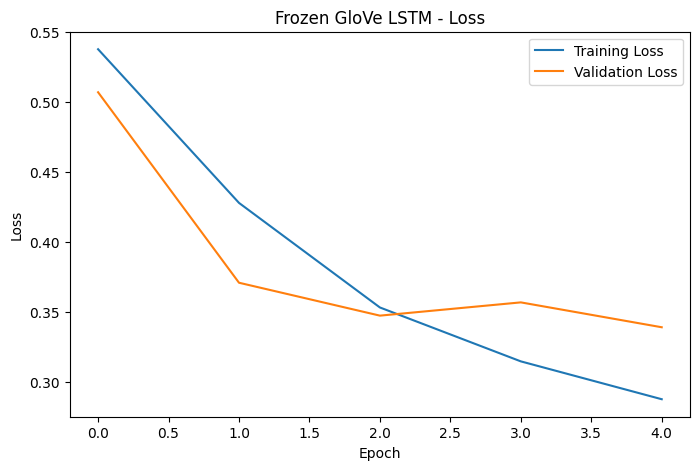

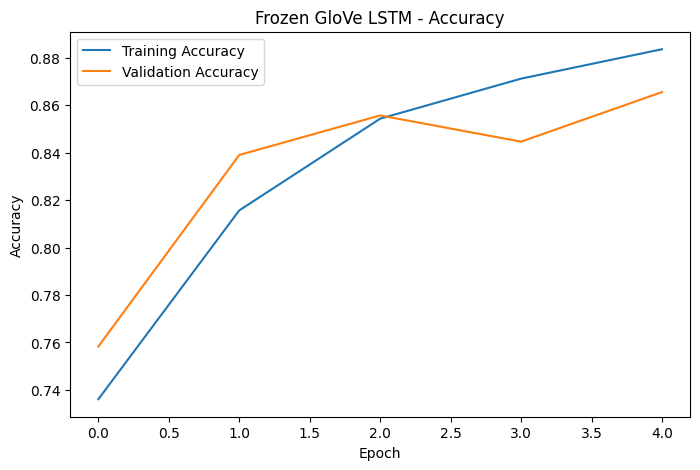

In [70]:
plot_training_history(
    glove_frozen_history,
    "Frozen GloVe LSTM"
)

In [71]:
import gc

del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine tuned GloVe LSTM 

In [72]:
glove_finetuned_model = LSTMClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    glove_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

print("Training Fine-Tuned GloVe LSTM...")
print("Device:", device)

glove_finetuned_history = train_model(
    model=glove_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_glove_finetuned.pt"
)

Training Fine-Tuned GloVe LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.4660 | Train Accuracy: 0.7827 | Val Loss: 0.3989 | Val Accuracy: 0.8251
Best model saved.
Epoch 02/5 | Train Loss: 0.2695 | Train Accuracy: 0.8971 | Val Loss: 0.2949 | Val Accuracy: 0.8805
Best model saved.
Epoch 03/5 | Train Loss: 0.1377 | Train Accuracy: 0.9535 | Val Loss: 0.3532 | Val Accuracy: 0.8779
Epoch 04/5 | Train Loss: 0.0565 | Train Accuracy: 0.9824 | Val Loss: 0.4262 | Val Accuracy: 0.8663
Epoch 05/5 | Train Loss: 0.0186 | Train Accuracy: 0.9951 | Val Loss: 0.5397 | Val Accuracy: 0.8671

Training completed in 3.81 minutes.


In [73]:
(
    glove_finetuned_metrics,
    glove_finetuned_labels,
    glove_finetuned_predictions,
    glove_finetuned_probabilities
) = evaluate_model(
    glove_finetuned_model,
    test_loader,
    device
)

print(glove_finetuned_metrics)

print(
    classification_report(
        glove_finetuned_labels,
        glove_finetuned_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        glove_finetuned_labels,
        glove_finetuned_predictions
    )
)

{'accuracy': 0.8726664247409379, 'precision': 0.862578125, 'recall': 0.887540192926045, 'f1': 0.8748811410459588}
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87     12361
    Positive       0.86      0.89      0.87     12440

    accuracy                           0.87     24801
   macro avg       0.87      0.87      0.87     24801
weighted avg       0.87      0.87      0.87     24801

[[10602  1759]
 [ 1399 11041]]


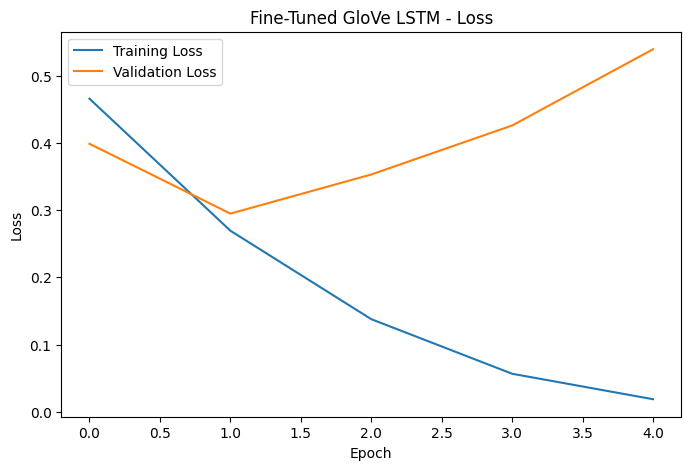

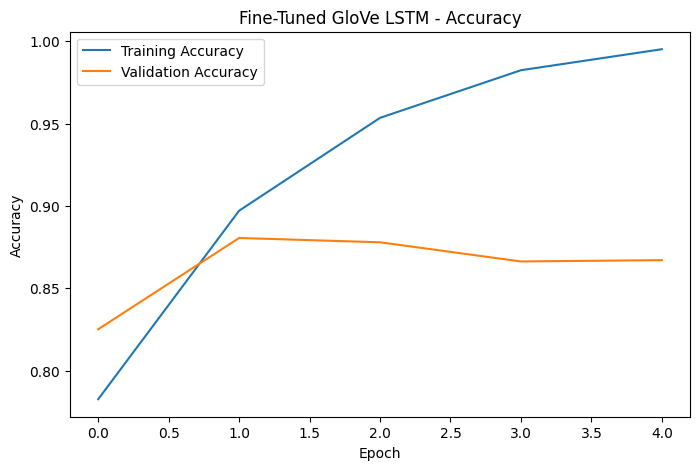

In [74]:
plot_training_history(
    glove_finetuned_history,
    "Fine-Tuned GloVe LSTM"
)

In [75]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Frozen word2Vec LSTM

In [76]:
word2vec_frozen_model = LSTMClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        word2vec_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Training Frozen Word2Vec LSTM...")
print("Device:", device)

word2vec_frozen_history = train_model(
    model=word2vec_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_word2vec_frozen.pt"
)

Training Frozen Word2Vec LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.4452 | Train Accuracy: 0.7999 | Val Loss: 0.3403 | Val Accuracy: 0.8589
Best model saved.
Epoch 02/5 | Train Loss: 0.3590 | Train Accuracy: 0.8552 | Val Loss: 0.3858 | Val Accuracy: 0.8384
Epoch 03/5 | Train Loss: 0.3224 | Train Accuracy: 0.8702 | Val Loss: 0.3288 | Val Accuracy: 0.8741
Best model saved.
Epoch 04/5 | Train Loss: 0.2891 | Train Accuracy: 0.8854 | Val Loss: 0.2750 | Val Accuracy: 0.8908
Best model saved.
Epoch 05/5 | Train Loss: 0.2674 | Train Accuracy: 0.8942 | Val Loss: 0.2769 | Val Accuracy: 0.8872

Training completed in 3.45 minutes.


In [77]:
(
    word2vec_frozen_metrics,
    word2vec_frozen_labels,
    word2vec_frozen_predictions,
    word2vec_frozen_probabilities
) = evaluate_model(
    word2vec_frozen_model,
    test_loader,
    device
)

print(word2vec_frozen_metrics)

print(
    classification_report(
        word2vec_frozen_labels,
        word2vec_frozen_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        word2vec_frozen_labels,
        word2vec_frozen_predictions
    )
)

{'accuracy': 0.88653683319221, 'precision': 0.8780832678711704, 'recall': 0.8985530546623794, 'f1': 0.8882002383790226}
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88     12361
    Positive       0.88      0.90      0.89     12440

    accuracy                           0.89     24801
   macro avg       0.89      0.89      0.89     24801
weighted avg       0.89      0.89      0.89     24801

[[10809  1552]
 [ 1262 11178]]


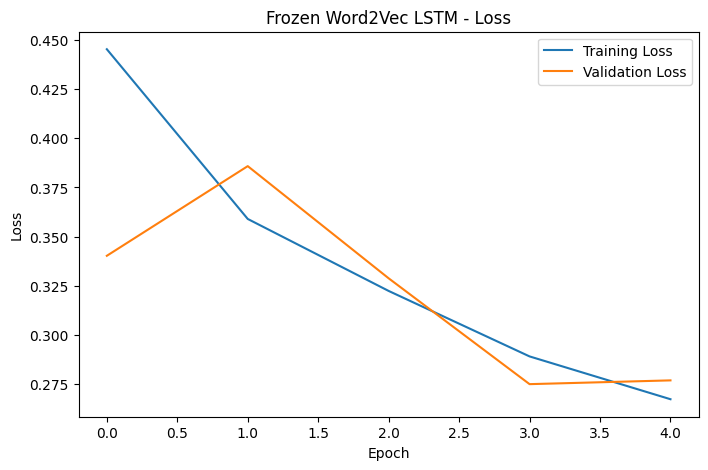

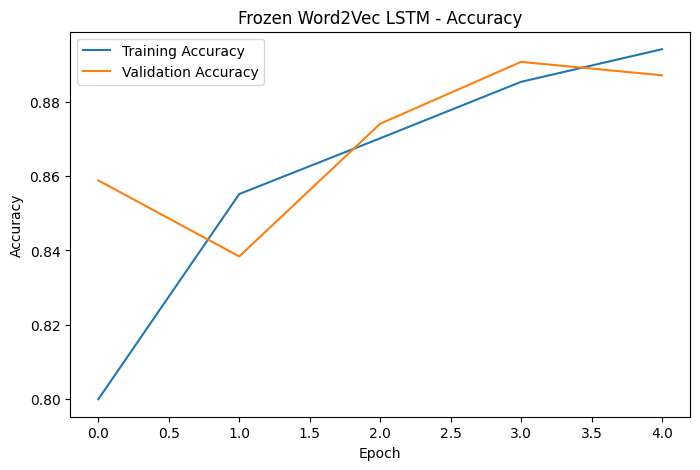

In [78]:
plot_training_history(
    word2vec_frozen_history,
    "Frozen Word2Vec LSTM"
)

In [79]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine tuned word2Vec LSTM

In [80]:
word2vec_finetuned_model = LSTMClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    word2vec_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

print("Training Fine-Tuned Word2Vec LSTM...")
print("Device:", device)

word2vec_finetuned_history = train_model(
    model=word2vec_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_word2vec_finetuned.pt"
)

Training Fine-Tuned Word2Vec LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.4006 | Train Accuracy: 0.8292 | Val Loss: 0.4399 | Val Accuracy: 0.8085
Best model saved.
Epoch 02/5 | Train Loss: 0.2527 | Train Accuracy: 0.9076 | Val Loss: 0.3140 | Val Accuracy: 0.8834
Best model saved.
Epoch 03/5 | Train Loss: 0.1575 | Train Accuracy: 0.9464 | Val Loss: 0.3070 | Val Accuracy: 0.8896
Best model saved.
Epoch 04/5 | Train Loss: 0.0906 | Train Accuracy: 0.9710 | Val Loss: 0.3700 | Val Accuracy: 0.8866
Epoch 05/5 | Train Loss: 0.0426 | Train Accuracy: 0.9884 | Val Loss: 0.5189 | Val Accuracy: 0.8667

Training completed in 4.04 minutes.


In [81]:
(
    word2vec_finetuned_metrics,
    word2vec_finetuned_labels,
    word2vec_finetuned_predictions,
    word2vec_finetuned_probabilities
) = evaluate_model(
    word2vec_finetuned_model,
    test_loader,
    device
)

print(word2vec_finetuned_metrics)

print(
    classification_report(
        word2vec_finetuned_labels,
        word2vec_finetuned_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        word2vec_finetuned_labels,
        word2vec_finetuned_predictions
    )
)

{'accuracy': 0.8669408491593081, 'precision': 0.889267461669506, 'recall': 0.8392282958199357, 'f1': 0.8635235732009926}
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87     12361
    Positive       0.89      0.84      0.86     12440

    accuracy                           0.87     24801
   macro avg       0.87      0.87      0.87     24801
weighted avg       0.87      0.87      0.87     24801

[[11061  1300]
 [ 2000 10440]]


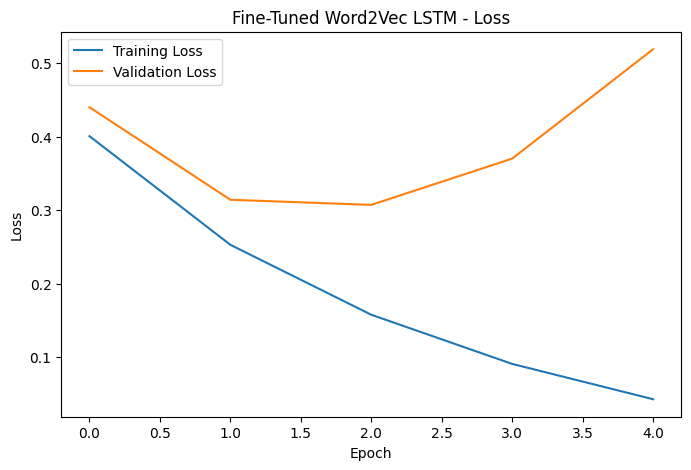

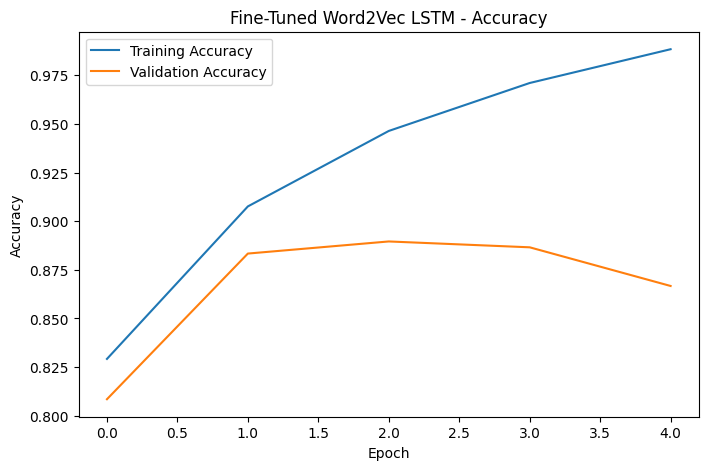

In [82]:
plot_training_history(
    word2vec_finetuned_history,
    "Fine-Tuned Word2Vec LSTM"
)

# Results Comparison

In [83]:
results = [
    {
        "Model": "LSTM",
        "Embedding": "GloVe",
        "Variant": "Frozen",
        **glove_frozen_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "GloVe",
        "Variant": "Fine-Tuned",
        **glove_finetuned_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "Word2Vec",
        "Variant": "Frozen",
        **word2vec_frozen_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "Word2Vec",
        "Variant": "Fine-Tuned",
        **word2vec_finetuned_metrics
    }
]

results_df = pd.DataFrame(results)

results_df

,Model,Embedding,Variant,accuracy,precision,recall,f1
0,LSTM,GloVe,Frozen,0.866820,0.917024,0.807556,0.858816
1,LSTM,GloVe,Fine-Tuned,0.872666,0.862578,0.887540,0.874881
2,LSTM,Word2Vec,Frozen,0.886537,0.878083,0.898553,0.888200
3,LSTM,Word2Vec,Fine-Tuned,0.866941,0.889267,0.839228,0.863524


In [84]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    RESULTS_DIR / "lstm_results.csv",
    index=False
)

print("Results saved.")

Results saved.


# Errors analysis

# Save the best model